# 1.1 价格与收益率

> **这一节讲什么？**  
> 学量化交易，第一步不是策略，而是搞清楚 **「涨了多少」怎么衡量**。
> 苹果从 100 元涨到 110 元，和从 1000 元涨到 1010 元，哪个涨得更多？
> 答案当然是前者——所以我们不看价格的绝对变化，而是看**收益率**（百分比变化）。

## 学习目标
- 理解金融资产价格的表示方式
- 掌握简单收益率与对数收益率的计算
- 理解二者的区别与适用场景
- 用 Python 计算真实股票数据的收益率

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf




# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
print('导入完成 ')

导入完成 


## 1. 下载真实数据

我们用苹果公司（AAPL）的历史数据来练手。下载下来的每行数据代表一天，包含：
- **Open**：开盘价（当天第一笔交易的价格）
- **High / Low**：当天最高 / 最低价
- **Close**：收盘价（当天最后一笔交易的价格）—— **我们最常用这个**
- **Volume**：当天成交量（交易了多少股）

In [ ]:
# 下载苹果公司 (AAPL) 近两年日线数据
ticker = 'AAPL'
data = yf.download(ticker, start='2022-01-01', end='2024-01-01', progress=False)
price = data['Close'].squeeze()  # 收盘价，squeeze作用是降维，把只有一列的二维 DataFrame 压成一维 Series

print(f'数据形状: {data.shape}')
print(f'时间范围: {price.index[0].date()} → {price.index[-1].date()}')
data[['Open', 'High', 'Low', 'Close', 'Volume']].tail()

数据形状: (501, 5)
时间范围: 2022-01-03 → 2023-12-29


Price,Open,High,Low,Close,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-12-22,193.173224,193.400870,190.985954,191.609482,37149600
2023-12-26,191.619364,191.896484,190.847385,191.065125,28919300
2023-12-27,190.510860,191.510470,189.125245,191.164062,48087700
2023-12-28,192.143916,192.658574,191.183888,191.589676,34049900
2023-12-29,191.906370,192.401229,189.758683,190.550461,42672100


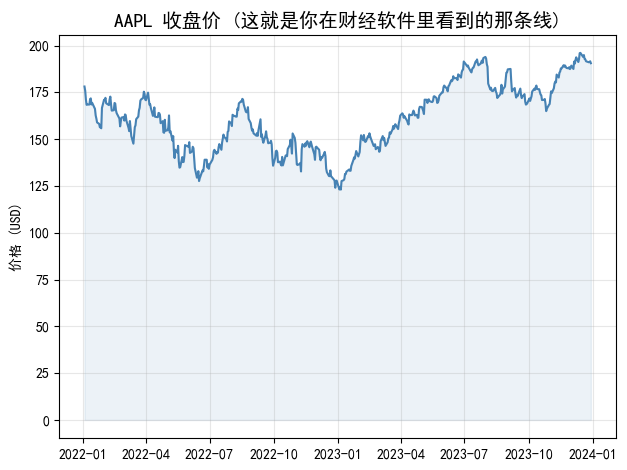

In [11]:
# 绘制收盘价走势

fig, ax = plt.subplots()
ax.plot(price.index, price.values, color='steelblue', linewidth=1.5)
ax.fill_between(price.index, price.values, alpha=0.1, color='steelblue')
ax.set_title(f'{ticker} 收盘价 (这就是你在财经软件里看到的那条线)', fontsize=14)
ax.set_ylabel('价格 (USD)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 简单收益率 (Simple Return)

### 为什么不直接用价格变化？

假设你买了股票 A，昨天 100 元，今天 105 元，赚了 5 元。
同时你朋友买了股票 B，昨天 1000 元，今天 1005 元，也赚了 5 元。

谁的投资表现更好？**显然是你**，因为你只用了 100 元，赚了 5%；你朋友用了 1000 元，只赚了 0.5%。

这就是为什么金融里我们用**百分比收益率**而不是绝对价格变化：

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

### 简单收益率的特点
- **直观易懂**：-5% 就是亏了 5%，就是这么简单
- **多资产可以加权平均**：如果你同时持有 A 和 B 各 50%，组合收益率 = 0.5×A + 0.5×B
- **跨期计算要相乘**：2 天累积收益 = (1+r₁)(1+r₂) - 1，不能直接加

In [4]:
# 计算简单日收益率（pct_change 就是 (今天-昨天)/昨天）
simple_ret = price.pct_change().dropna()

print('简单收益率统计：')
print(simple_ret.describe().round(4))
print(f'\n最大单日收益: {simple_ret.max():.2%}  （赚最多的那天）')
print(f'最大单日亏损: {simple_ret.min():.2%}  （亏最多的那天）')

简单收益率统计：
count    500.0000
mean       0.0003
std        0.0183
min       -0.0587
25%       -0.0097
50%        0.0006
75%        0.0101
max        0.0890
Name: AAPL, dtype: float64

最大单日收益: 8.90%  （赚最多的那天）
最大单日亏损: -5.87%  （亏最多的那天）


- count: 500.0000
含义：有效数据有 500 个交易日
为什么是 500：原始收盘价有 501 天，pct_change() 后第一天变成 NaN，dropna() 删掉后就剩 500 天
- mean: 0.0003
含义：日均收益率 0.03%
换算：如果一年有 252 个交易日，年化收益约 0.0003 × 252 ≈ 7.56%
- std: 0.0183
含义：日收益率的标准差是 1.83%
解读：每天涨跌幅的典型波动在 ±1.83% 左右。这是衡量风险的核心指标
- min: -0.0587
含义：这 500 天里，跌得最惨的一天跌了 5.87%
解读：这是回测期间的单日最大亏损，用来评估极端风险
- 25%: -0.0097
含义：有 25% 的交易日，收益率低于 -0.97%
解读：在所有交易日里，有 25% 的交易日，收益率低于 -0.0097（即 -0.97%）。
- 50%: 0.0006
含义：中位数，一半的交易日收益率低于 0.06%
解读：涨跌天数差不多，中位数接近零，说明涨跌分布比较对称
- 75%: 0.0101
含义：有 75% 的交易日，收益率低于 1.01%
解读：反过来，有 25% 的交易日涨幅超过 1%
- max: 0.0890
含义：涨得最猛的一天涨了 8.90%
解读：单日最大涨幅，和 min 对比，最大跌幅 5.87% vs 最大涨幅 8.90%，说明大涨的日子比大跌的日子更极端



## 3. 对数收益率 (Log Return)

### 为什么会有「对数」收益率这东西？

对数收益率是量化分析师和研究者更常用的方式，原因有两个：

**① 跨期直接相加（不用乘法了）**  
简单收益率跨期要相乘（很麻烦）：$(1+r_1)(1+r_2)\cdots$  
对数收益率跨期直接相加：$r^{log}_1 + r^{log}_2 + \cdots$  
这在数学推导中方便很多。

**② 更接近正态分布，便于统计建模**  
很多量化模型假设收益率是正态分布的，对数收益率更满足这个假设。

**③ 当涨跌幅很小时，两者几乎相等**  
（日线数据大多数时候两者差不超过 0.01%，可以互换）

$$r_t^{\log} = \ln\frac{P_t}{P_{t-1}} = \ln P_t - \ln P_{t-1}$$

> **结论：** 日常分析用简单收益率（直观），数学建模用对数收益率（方便）。

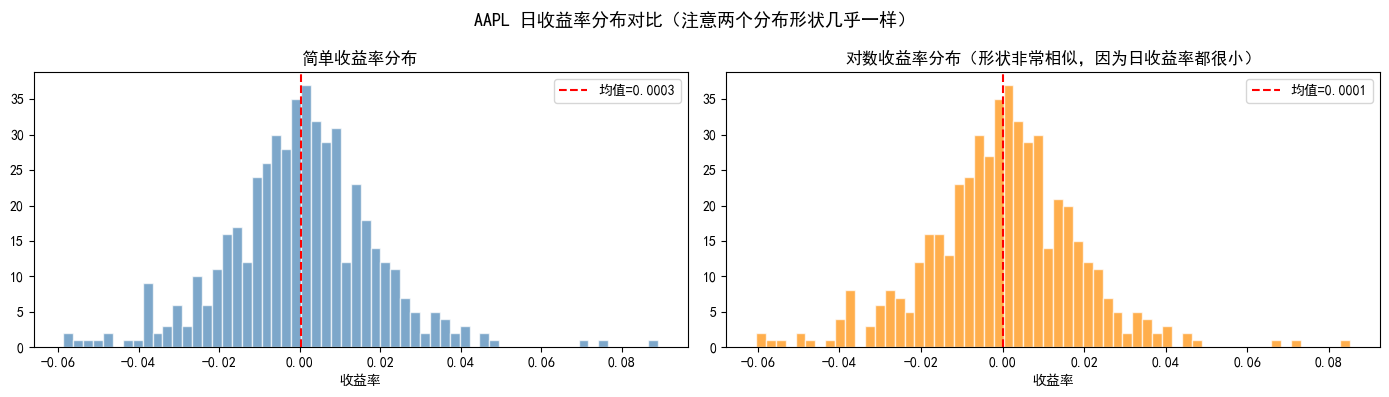

In [ ]:
# 计算对数收益率
log_ret = np.log(price / price.shift(1)).dropna()
price是当期价格，price.shift(1) 是前1期价格
# 对比两种收益率的分布形状
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(simple_ret, bins=60, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('简单收益率分布')
axes[0].set_xlabel('收益率')
axes[0].axvline(simple_ret.mean(), color='red', linestyle='--', label=f'均值={simple_ret.mean():.4f}')
axes[0].legend()

axes[1].hist(log_ret, bins=60, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].set_title('对数收益率分布（形状非常相似，因为日收益率都很小）')
axes[1].set_xlabel('收益率')
axes[1].axvline(log_ret.mean(), color='red', linestyle='--', label=f'均值={log_ret.mean():.4f}')
axes[1].legend()

plt.suptitle(f'{ticker} 日收益率分布对比（注意两个分布形状几乎一样）', fontsize=13)
plt.tight_layout()
plt.show()

## 4. 累积收益率

### 「买了这只股票，现在挣了多少」怎么算？

这就是累积收益率要回答的问题。  
把每天的收益率「复利」地乘起来，就得到了从第一天到现在的总收益：

$$\text{累积收益率}_t = (1+r_1) \times (1+r_2) \times \cdots \times (1+r_t) - 1$$

变成代码就是：`(1 + daily_returns).cumprod() - 1`

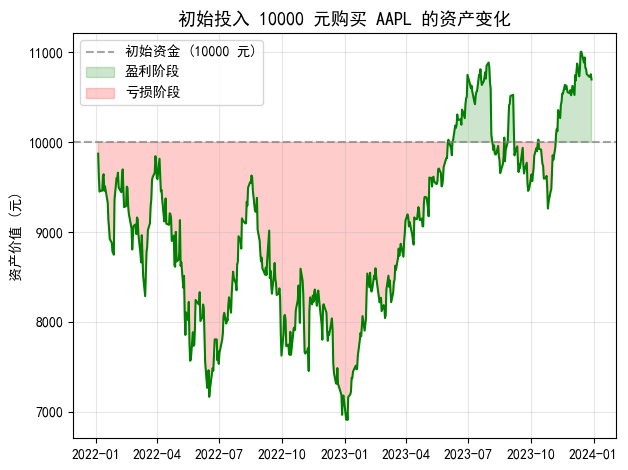

总收益率: 6.99%
最终资产: 10698.85 元


In [6]:
# 计算累积收益率（假设初始投入 10000 元）
initial_capital = 10000
cumulative_ret = (1 + simple_ret).cumprod()
portfolio_value = cumulative_ret * initial_capital

fig, ax = plt.subplots()
ax.plot(portfolio_value.index, portfolio_value.values, color='green', linewidth=1.5)
ax.axhline(initial_capital, color='gray', linestyle='--', alpha=0.7, label='初始资金 (10000 元)')
ax.fill_between(portfolio_value.index, initial_capital, portfolio_value.values,
                where=(portfolio_value.values >= initial_capital),
                alpha=0.2, color='green', label='盈利阶段')
ax.fill_between(portfolio_value.index, initial_capital, portfolio_value.values,
                where=(portfolio_value.values < initial_capital),
                alpha=0.2, color='red', label='亏损阶段')
ax.set_title(f'初始投入 {initial_capital} 元购买 {ticker} 的资产变化', fontsize=13)
ax.set_ylabel('资产价值 (元)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

total_return = cumulative_ret.iloc[-1] - 1
print(f'总收益率: {total_return:.2%}')
print(f'最终资产: {portfolio_value.iloc[-1]:.2f} 元')

## 5. 年化收益率

### 为什么要「年化」？

假设策略 A 持有了 3 个月，赚了 5%；策略 B 持有了 3 年，赚了 30%。哪个更好？

直接比较 5% vs 30% 不公平，因为持有时间不同。**年化收益率就是把所有策略换算成「每年赚多少」，方便横向比较。**

$$\text{年化收益率} = (1 + \text{总收益率})^{\frac{252}{T}} - 1$$

- $T$：实际持有的交易日数
- $252$：美股一年约 252 个交易日（去掉周末和节假日）
- $\frac{252}{T}$：这是「持有了几年」的倒数——1年变成年化就乘以 1，半年就乘以 2

In [7]:
T = len(simple_ret)  # 交易日数
total_ret = cumulative_ret.iloc[-1] - 1
annual_ret = (1 + total_ret) ** (252 / T) - 1

print(f'持有交易日数: {T} 天（约 {T/252:.1f} 年）')
print(f'总收益率:     {total_ret:.2%}')
print(f'年化收益率:   {annual_ret:.2%}  ← 每年平均赚这么多')

持有交易日数: 500 天（约 2.0 年）
总收益率:     6.99%
年化收益率:   3.46%  ← 每年平均赚这么多


## 6. 🎯 练习

1. 将 `ticker = 'AAPL'` 改为你感兴趣的其他股票（如 `'TSLA'`, `'MSFT'`, `'GOOGL'`），重新运行所有单元格，观察结果差异。
2. 计算 2023 年全年的年化收益率（提示：修改下载的起止时间）。
3. 对比同一时期多支股票的累积收益率曲线（在同一张图上绘制多条线）。

---

**下一节** → `02_risk_and_volatility.ipynb`